**Made by LARBAOUI Yasmine Bade Elhouda**

In this Notebook , I implemented a **Generative Adversial Network (GAN)** to generate **Cartoon faces**

1. Download and preprocess a dataset of cartoon faces.

2. Building the Generator and Discriminator networks.

3. Training the GAN and visualize how the Generator improves over time.

4. Compare generated images with real cartoon faces to evaluate the results.

In [ ]:
# Check GPU
!nvidia-smi

Thu Jan 29 15:17:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

##**Import Libraries**

In [ ]:
import torch # core pytorch used for tensor operations and deep learning
import torch.nn as nn # neural network module (Layers , activations , Loss function ...)
import torch.optim as optim 3 to optimize the trainig
from torch.utils.data import DataLoader #used for Load dataset in batches during trainig
from torchvision import transforms, datasets
from torchvision.utils import make_grid, save_image # visualise and save generated images
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import os

##**Data Processing**

###**Download the Cartoon Faces Dataset**

In [ ]:
import kagglehub
# Download the cartoon faces dataset
path = kagglehub.dataset_download("brendanartley/cartoon-faces-googles-cartoon-set")
print("Path to dataset files:", path)


Using Colab cache for faster access to the 'cartoon-faces-googles-cartoon-set' dataset.
Path to dataset files: /kaggle/input/cartoon-faces-googles-cartoon-set


###**Config & Parametrs**

\- Defining all key parameters that controll the GAN training and image generation

\- latent_DIM = 100 : the dimensionality of the **latent space** which is the random input space of the **Generator** , so the generator learns a mapping (Z latent vector -> image)

\- z is sampled from a simple distribution (usually gaussian or uniform )

\- generator is not memorizing images , but learning to transofmr abstract noise into structed data

In [ ]:
IMG_SIZE = 64 # size to which all images will be resized (64*64)
BATCH_SIZE = 128
LATENT_DIM = 100  # Size of the random noise vector fed into the Generator
EPOCHS = 10
LR = 0.0002    # Learning rate for both Generator and Discriminator optimizers

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# dir where to store generated images during the trainig
SAMPLE_DIR = "samples"
os.makedirs(SAMPLE_DIR, exist_ok=True)
print("Using device:", DEVICE)

Using device: cuda


###**Dataset & DataLoader**

preparing the real images before show to the Descriminator

In [ ]:
#dataset_dir = "/root/.cache/kagglehub/datasets/brendanartley/cartoon-faces-googles-cartoon-set/versions/1"
dataset_dir = path # true data distribution that the GAN tries to lean

transform = transforms.Compose([ # preprocessing steps for the sequence of images
    transforms.Resize(IMG_SIZE), # resize image so all have the same dimensions
    transforms.CenterCrop(IMG_SIZE), # crop the center to get a square image
    transforms.ToTensor(), # convert images to Pytorch tensor
    transforms.Normalize([0.5]*3, [0.5]*3)  # Scale [-1,1] # Normalize pixels to [-1 , 1] for GAN stability
])

\- creating dataset that represents the real image distribution the GAN will learn from

\- getting the dataset from the dataset_dir and applying the preprocessing steps defined in the previous cell  

In [ ]:
dataset = datasets.ImageFolder(
    root=dataset_dir,  # real images folder
    transform=transform # apply preprocessing before feeding images to the GAN
)

Creating the Data Loaderr to feeds real images to the GAN during the trainig

In [ ]:
loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,

    # shuffle will randomize the order of images every epoch so the Discriminator
    # doesn’t memorize the sequence and learns general features instead
    shuffle=True,
    num_workers=2 # 2 cpu threads to load images in parallel
)

###**Visualize Real Images**

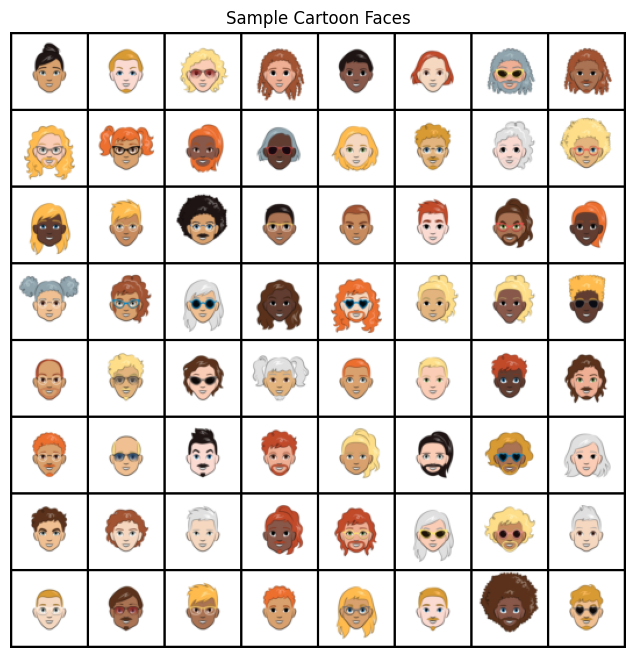

In [ ]:
real_batch = next(iter(loader))[0][:64]

plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Sample Cartoon Faces")
plt.imshow(np.transpose(make_grid(real_batch, padding=2, normalize=True), (1,2,0)))
plt.show()


##**Implementation of the Model**

###**Generator**

The Generator is a network that creates images from **random noise (latent vectors)**.

\- It learns to map points from a latent space to realistic images that resemble the training data.

\- During training, it receives feedback from the Discriminator about how real or fake its generated images look.

\- The Generator gradually transforms the **low-dimensional noise vector** into a **high-dimensional image**, building structure, patterns, and textures step by step.

\- It uses non-linear transformations and normalization to model complex visual features and ensure stable learning.

\- The output is a 3-channel RGB image with pixel values scaled to match the training images.

    Through adversarial training, the Generator improves over time by learning to produce images that can fool the Discriminator into classifying them as real.

In [ ]:

def build_generator(latent_dim):
    model = nn.Sequential(
        # expand Latent vector to feature map (512 channels)
        nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),
        nn.BatchNorm2d(512), # normalize
        nn.ReLU(True), # activation for non-linearity : so Generator can model complex patterns

        nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False), # unsample to larger feature map
        nn.BatchNorm2d(256),
        nn.ReLU(True),

        nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False), # unsample again
        nn.BatchNorm2d(128),
        nn.ReLU(True),

        nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
        nn.BatchNorm2d(64),
        nn.ReLU(True),

        nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False), # Final Layer output 3-channel RGB image
        nn.Tanh() # scale pixels to [-1 , 1]
    )
    return model


###**Discriminator**

\- Discriminator is a binary classifier which will distinguish real images from fake images produced by the generator

\- it learns the distribution of real images by observing patterns , textures , and structures common in the trainig data

\- during the trainig it receives real images from dataset & fake images from generator

\- will progressively transforming input images into a high-level representation (captures essential features)

\- by coparing these features to what it has learned from images -> discriminator will produces a score representing the likelihood of an image being real

      through the training , the discriminator will constatly updates it **understanding** of what real looks like while the generator will uses this feedback to improve its outputs


In [ ]:
def build_discriminator():
    model = nn.Sequential(
        # extracts 64 basic feature maps from a 3-channel RGB Image
        # then the image is reduced in size to make it easier to process
        nn.Conv2d(3, 64, 4, 2, 1, bias=False),

        # Non linearity to learn complexe patterns
        # LeakyRELU allows small negative values to pass through
        nn.LeakyReLU(0.2, inplace=True),

        # extracts 128 more detailed feature from the previous 64 features map
        nn.Conv2d(64, 128, 4, 2, 1, bias=False),
        nn.BatchNorm2d(128),
        nn.LeakyReLU(0.2, inplace=True),

        nn.Conv2d(128, 256, 4, 2, 1, bias=False),
        nn.BatchNorm2d(256),
        nn.LeakyReLU(0.2, inplace=True),

        nn.Conv2d(256, 512, 4, 2, 1, bias=False),
        nn.BatchNorm2d(512),
        nn.LeakyReLU(0.2, inplace=True),

        # reducing all the extracted features to a single number
        # this number represents how real image looks
        nn.Conv2d(512, 1, 4, 1, 0, bias=False),
        # convert the number into a probability between 0 and 1
        # 1 : real image 0 : fake
        nn.Sigmoid()
    )
    return model


In [ ]:
# create and move the Generator & discriminator to the device
G = build_generator(LATENT_DIM).to(DEVICE)
D = build_discriminator().to(DEVICE)


###**Optimizers & Loss**

In [ ]:
criterion = nn.BCELoss() # Binary cross-entropy loss for real/fake classification
# optimizer for Generator
opt_G = torch.optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
# optimizer for Discriminator
opt_D = torch.optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))

'''
GAN generate images from random noise vectors , not directly from images
fixed_noise set of noise vectors that we do not change , so we can compare generated images across epochs and visually see progress
sahepe (64,latentd_dim,1,1) : the convTransposed2D expects a 4D tensor [batch , channels , heights , width]
'''
fixed_noise = torch.randn(64, LATENT_DIM, 1, 1).to(DEVICE)
img_list = [] # storing the generated images for visualization
G_losses = [] # track generator Loss over epochs
D_losses = [] # track discriminator loss over epochs


##**Training**

###**Trainig Loop**

1. discriminator :

\- The Discriminator looks at a batch of real images from the dataset and labels them as real (1).

\- It also looks at a batch of fake images generated by the Generator from random noise and labels them as fake (0).

\- Using these real and fake examples, the Discriminator updates its parameters to better distinguish real images from generated ones.

2. generator :    

\- The Generator produces a new batch of fake images from random noise.

\- The Discriminator evaluates these images, but the Generator’s loss is computed as if these images were real (1).

\- This encourages the Generator to improve its outputs so the Discriminator is more likely to classify them as real.

3. At the end of each epoch, the Generator produces images from a fixed set of random noise vector

       the Discriminator learns to separate real from fake, while the Generator learns to produce images that can fool the Discriminator.

In [ ]:
for epoch in range(EPOCHS):
    # loop over batches of real images
    for real, _ in tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):

        real = real.to(DEVICE) # real images to GPU
        b_size = real.size(0) # Number of images in the current batch

        ''' create real labels : number for each image that tells the discriminator
        this image is real (1) '''
        real_labels = torch.ones(b_size, device=DEVICE)


        ''' create fake labels : number for each fake image that tells the discriminator
        this image is fake (0) '''
        fake_labels = torch.zeros(b_size, device=DEVICE)

        # --- Train Discriminator ----------------------------------------------
        # ----------------------------------------------------------------------

        # generate random noise vectors that the generator will use to make fake images
        z = torch.randn(b_size, LATENT_DIM, 1, 1).to(DEVICE)

        fake = G(z) # generator creates fake images from this noise

        # discriminator looks at real images and predicts a number for each
        # how real is the image (? close to 1)
        D_real = D(real).view(-1)

        # discriminator looks at fake images and predict number for each
        # detach() prevents gradients from flowing back to the Generator
        D_fake = D(fake.detach()).view(-1)

        # compare discriminator predictions with the correct answers
        # loss measures how well the discriminator is doing
        loss_D = criterion(D_real, real_labels) + criterion(D_fake, fake_labels)

        opt_D.zero_grad() # clear previous gradients
        loss_D.backward() # backpropagate discriminator Loss
        opt_D.step() # update discriminator weights

        # --- Train Generator --------------------------------------------------
        # ----------------------------------------------------------------------
        ''' Pass fake images through discriminator again
        this time the generator wants the discriminator thinks ther are real '''
        output = D(fake).view(-1)

        # compare discriminator's prediction with real labels (1)
        # the generator is rewarded when the discriminator thinks its image are real
        loss_G = criterion(output, real_labels)

        opt_G.zero_grad() # clear the previous gradients
        loss_G.backward() # backpropagate generator loss
        opt_G.step() # update generator weights

    # save Generator and Discriminator Loss
    G_losses.append(loss_G.item())
    D_losses.append(loss_D.item())

    # Save sample images using fixed noise
    with torch.no_grad():

        # generate fake images from fixed noise
        fake_samples = G(fixed_noise).detach().cpu()

        # Save a grid of images for visual tracking
        img_list.append(make_grid(fake_samples, padding=2, normalize=True))

    print(f"Epoch {epoch+1} | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")


Epoch 1/10: 100%|██████████| 782/782 [07:12<00:00,  1.81it/s]


Epoch 1 | D Loss: 0.1752 | G Loss: 4.0006


Epoch 2/10: 100%|██████████| 782/782 [04:42<00:00,  2.77it/s]


Epoch 2 | D Loss: 0.1978 | G Loss: 3.1295


Epoch 3/10: 100%|██████████| 782/782 [04:35<00:00,  2.84it/s]


...

Epoch 8 | D Loss: 0.1221 | G Loss: 2.9538


Epoch 9/10: 100%|██████████| 782/782 [04:32<00:00,  2.87it/s]


Epoch 9 | D Loss: 0.0201 | G Loss: 6.4140


Epoch 10/10: 100%|██████████| 782/782 [04:33<00:00,  2.86it/s]

Epoch 10 | D Loss: 0.0116 | G Loss: 6.4289


###**Loss Visualization**

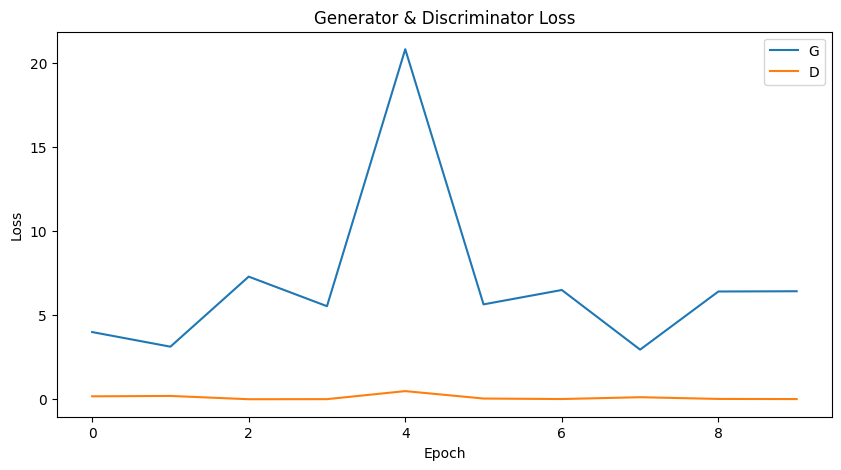

In [ ]:
plt.figure(figsize=(10,5))
plt.title("Generator & Discriminator Loss")
plt.plot(G_losses, label="G")
plt.plot(D_losses, label="D")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


###**Interpretation**

- Discriminator's loss starts low and fluctuates throughout trainig
- loss D loss : discriminator is very confident in telling real from fake image
- fluctuationss are normal because the generator is also improving , so when generator make better fake images , the discriminator has a harder time which mean loss can increase temporarily

- Genartor's loss start high then varies
- high G loss mneas that the generator is failing to fool the discriminator , low G loss meas its  doing better
- the spikes and drops are normal in GAN (Generator & discriminator) because as one improves the other reacts

##**GAN Results**

###**Visualize Generated Cartoon Faces**

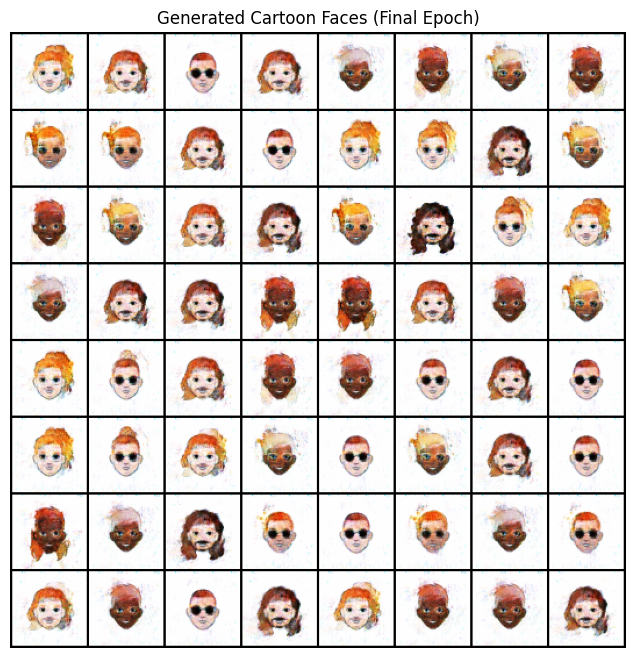

In [ ]:
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Generated Cartoon Faces (Final Epoch)")
plt.imshow(np.transpose(img_list[-1], (1,2,0)))
plt.show()


###**Real vs Fake Comparison**

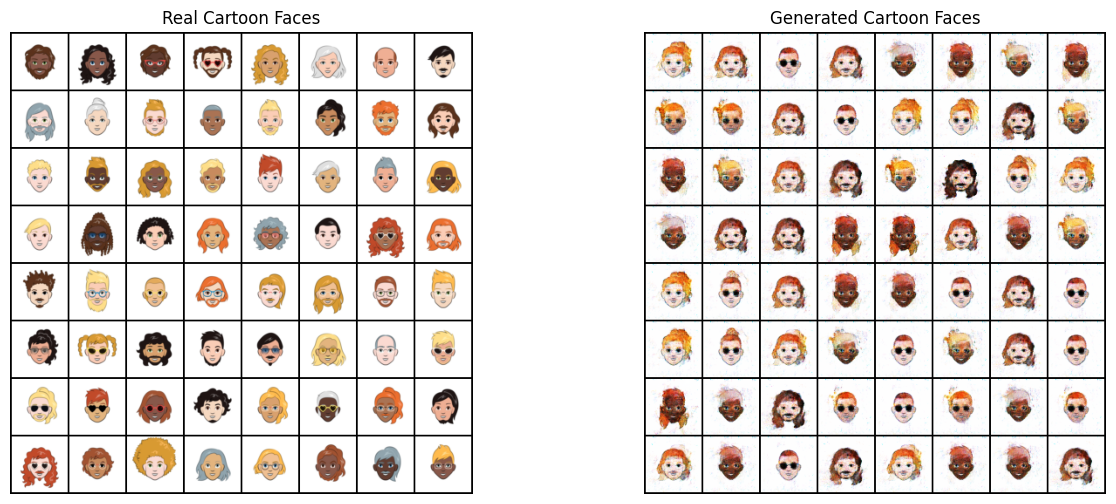

In [ ]:
real_batch = next(iter(loader))[0][:64]

plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.title("Real Cartoon Faces")
plt.axis("off")
plt.imshow(np.transpose(make_grid(real_batch, normalize=True), (1,2,0)))

plt.subplot(1,2,2)
plt.title("Generated Cartoon Faces")
plt.axis("off")
plt.imshow(np.transpose(img_list[-1], (1,2,0)))
plt.show()
